**Flux Plots for Different Deployments**

This will try to visualize flux on frying pan shoals over the five deployments.


In [1]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
from spectral_sediment import despiker
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
plt.rcParams.update({'font.size': 14}) 


deployment_num = [1, 2, 3]
sensor_spot = "C"
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

In [ ]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
    sensor_ids = glob.glob(os.path.join(initpath, f"{sensor_spot}[0-9]*"))
    for sensor_id in sensor_ids:
        sensor_location = os.path.basename(sensor_id)
        sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
        print(f"Processing {sensor_location}...")
        files = ["DepthAveragedFlowDirection", "DepthAveragedCurrentVelocity", "Vertavg","Echo1avg","Time","Sedtime"]
        waves = {}
        for file in files:
            file_path = os.path.join(sensor_id, file)  # file path
            df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
            file_name = file.split(".")[0]  # file name
            print(file_name)
            waves[file_name] = df  # store dataframe
        globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing CORMP...


FileNotFoundError: File Z:/deployment_1/BulkStats\CORMP_data\DepthAveragedFlowDirection does not exist

In [ ]:
#Create lists of what sensors are in each deployment
# 1. Define your categories based on your naming convention
sides = ['S', 'E', 'C']  # South, East, Central
landers = ['0', '1']
deployments = range(1, 6)

# 2. Organize variables into a nested dictionary
# This uses globals() to grab the actual data stored in those variable names
organized_waves = {}

for s in sides:
    for l in landers:
        for d in deployments:
            var_name = f"waves_{s}{l}_{d}"
            
            # Check if this specific combination exists in your workspace
            if var_name in globals():
                if s not in organized_waves: organized_waves[s] = {}
                if l not in organized_waves[s]: organized_waves[s][l] = {}
                
                # Store the data in the dict
                organized_waves[s][l][d] = globals()[var_name]

# Example automative loop 
# for side, lander_dict in organized_waves.items():
#     for lander_id, dep_dict in lander_dict.items():
#         for dep_num, data in dep_dict.items():
print(organized_waves.keys())

dict_keys(['S'])


In [ ]:
#Function to convert unix timestamp in ns to regular datetime in UTC
print(organized_waves['S']['0'][1]['Time'].values.squeeze()[0])  # Example of a timestamp in ns

2024-08-21T11:30:00.126107000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_orbital_bars(waves, title=None, cmap="viridis", normalize_velocity=False):
    """
    Polar orbital bar plot.

    Parameters
    ----------
    waves : dict
        Dictionary with keys:
        - DepthAveragedFlowDirection
        - DepthAveragedCurrentVelocity
        - Vertavg

    title : str
        Plot title

    cmap : str
        Matplotlib colormap

    normalize_velocity : bool
        Normalize bar length
    """

    # ----------------------------------
    # Extract data
    # ----------------------------------
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")

    direction = waves["DepthAveragedFlowDirection"].values.squeeze()
    velocity = waves["DepthAveragedCurrentVelocity"].values.squeeze()
    if echo ==True:
        vertavg = waves["Vertavg"].values.squeeze()
    if echo ==False:
        vertavg = waves["Echo1avg"].values.squeeze()
    #Downsample vert avg to match dir and vel length

    if len(vertavg) > len(direction):
        chunks = np.array_split(vertavg, len(direction))
        
        # Map the mean function across those chunks
        vertavg = np.array([np.mean(chunk) for chunk in chunks])

    # ----------------------------------
    # Bin Data into 10 degree bins
    # ----------------------------------
    print(direction.shape, vertavg.shape, velocity.shape)
    bins = np.arange(0, 360 + 10, 10)
    bin_indices = np.digitize(direction, bins) - 1  # Get bin
    bin_vertavg = np.array([np.nansum(vertavg[bin_indices == i]) for i in range(len(bins) - 1)])
    bin_theta = np.deg2rad((bins[:-1] + bins[1:]) / 2)  # Bin centers
    bin_width = np.deg2rad(10)  # Bin width
    bin_vel = np.array([np.nanmean(velocity[bin_indices == i]) for i in range(len(bins) - 1)])
    
    # ----------------------------------
    # Colors from Vertavg
    # ----------------------------------

    norm = plt.Normalize(np.nanmin(bin_vertavg), np.nanmax(bin_vertavg))
    cmap = plt.colormaps.get_cmap(cmap)
    colors = cmap(norm(bin_vertavg))

    # ----------------------------------
    # Plot
    # ----------------------------------
    print(bin_theta.shape, bin_vel.shape, bin_width.shape, colors.shape)
    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

    bars = ax.bar(bin_theta, bin_vel, width=bin_width, bottom=0, color=colors, alpha=0.8)
    
    # ----------------------------------
    # Formatting
    # ----------------------------------

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    if title:
        ax.set_title(title)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.colorbar(sm, ax=ax, label="Sum of Vertavg Intensity (dB)")
    plt.xlabel("Flow Direction (degrees)")
    plt.ylabel("Depth-Averaged Current Velocity (m/s)")
    plt.tight_layout()
    plt.show()

Echo data empty: True
(792,) (792,) (792,)
(36,) (36,) () (36, 4)


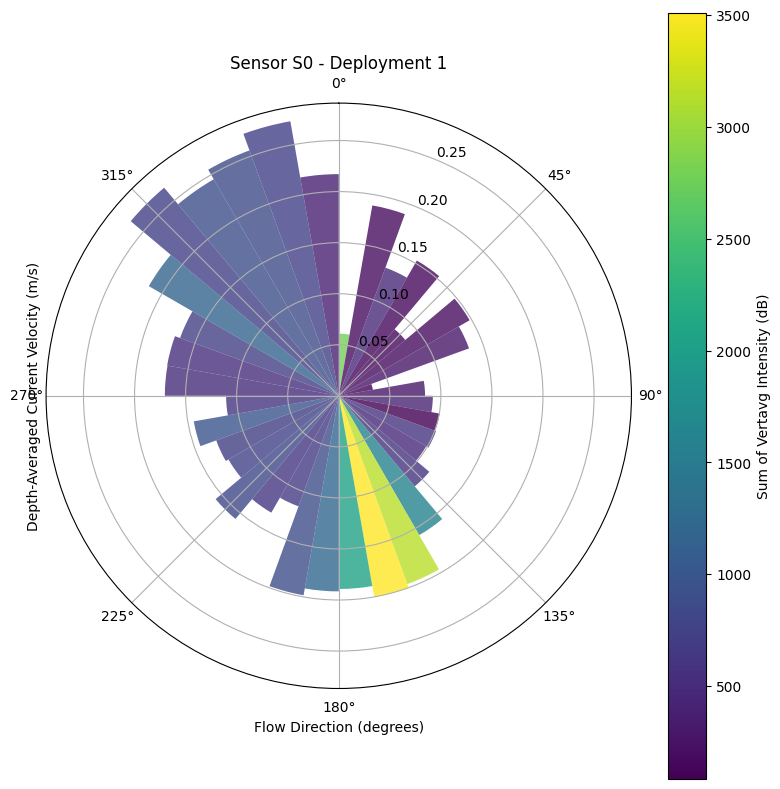

Echo data empty: True
(624,) (624,) (624,)
(36,) (36,) () (36, 4)


C:\Users\lwlav\AppData\Local\Temp\ipykernel_8132\2220627168.py:57: RuntimeWarning: Mean of empty slice
  bin_vel = np.array([np.nanmean(velocity[bin_indices == i]) for i in range(len(bins) - 1)])


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (0,)

<Figure size 800x800 with 2 Axes>

Echo data empty: True
(1320,) (1320,) (1320,)
(36,) (36,) () (36, 4)


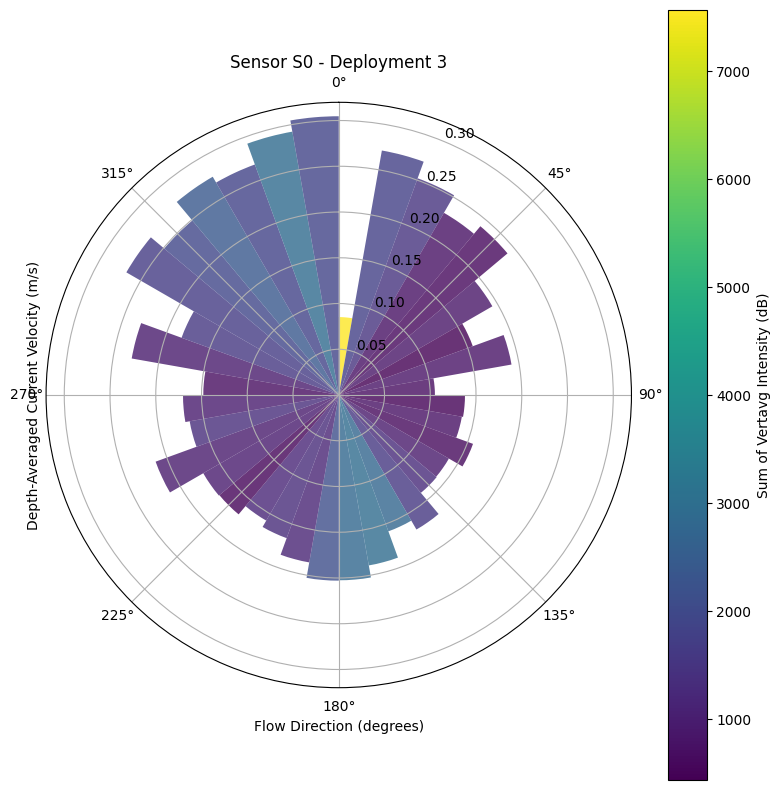

In [ ]:
global_variable_names = list(globals().keys())
for side, lander_dict in organized_waves.items():
    for lander_id, dep_dict in lander_dict.items():
        for dep_num, data in dep_dict.items():
            plot_orbital_bars(data, title=f"Sensor {side}{lander_id} - Deployment {dep_num}", normalize_velocity=True)

In [ ]:
#generate quiver plots
def plot_quiver_ampavg(waves, title=f"Sensor {side}{lander_id} - Deployment {dep_num} ",echo = False):
    #Check if echosounder contains data
    echo = waves["Echo1avg"].empty
    print(f"Echo data empty: {echo}")
    
    fig,axs = plt.subplots(2, 1, figsize=(20,5), sharex=True)
    v = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.cos(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))
    u = waves["DepthAveragedCurrentVelocity"].values.squeeze() * np.sin(np.deg2rad(waves["DepthAveragedFlowDirection"].values.squeeze()))

    x = waves['Time'].values.squeeze()
    y = np.zeros(x.shape)  # x can be zeros since we are only interested in the direction and magnitude of the vectors

    q = axs[0].quiver(x,y,u,v,waves['DepthAveragedCurrentVelocity'].values.squeeze(), cmap='viridis',scale =10)
    axs[0].quiverkey(q, X=0.9, Y=1.05, U=0.5, label='0.5 m/s', labelpos='E',)
    axs[0].set_title(title + " Quiver plot of Current Flows")
    axs[0].set_xlabel("Time")
    axs[0].set_ylim(3,-3)
    axs[0].set_xlim(waves['Time'].values.squeeze()[0], waves['Time'].values.squeeze()[-24*3])

    if echo == True:
        despiked_vert, mask = despiker(waves["Vertavg"],lam =3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_vert,label= 'Vertical Depth Averaged Amplitude')
        axs[1].set_xlabel("Time")
        axs[1].set_ylabel("Vertical Beam Amplitude (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(30, 60)
        axs[1].legend()

    if echo == False:
        despiked_echo, mask = despiker(waves["Echo1avg"], lam = 3)

        axs[1].plot(waves['Sedtime'].values.squeeze(), despiked_echo,label= 'Echo 1 Depth Averaged Amplitude')
        axs[1].set_xlabel("Time")
        axs[1].set_ylabel("Echosounder Beam Amplitude (dB)")
        axs[1].set_title(title + " Backscatter Intensity")
        axs[1].set_ylim(np.nanmin(despiked_echo), np.nanmax(despiked_echo))
        axs[1].legend()

    plt.tight_layout()
    plt.show()

Echo data empty: True


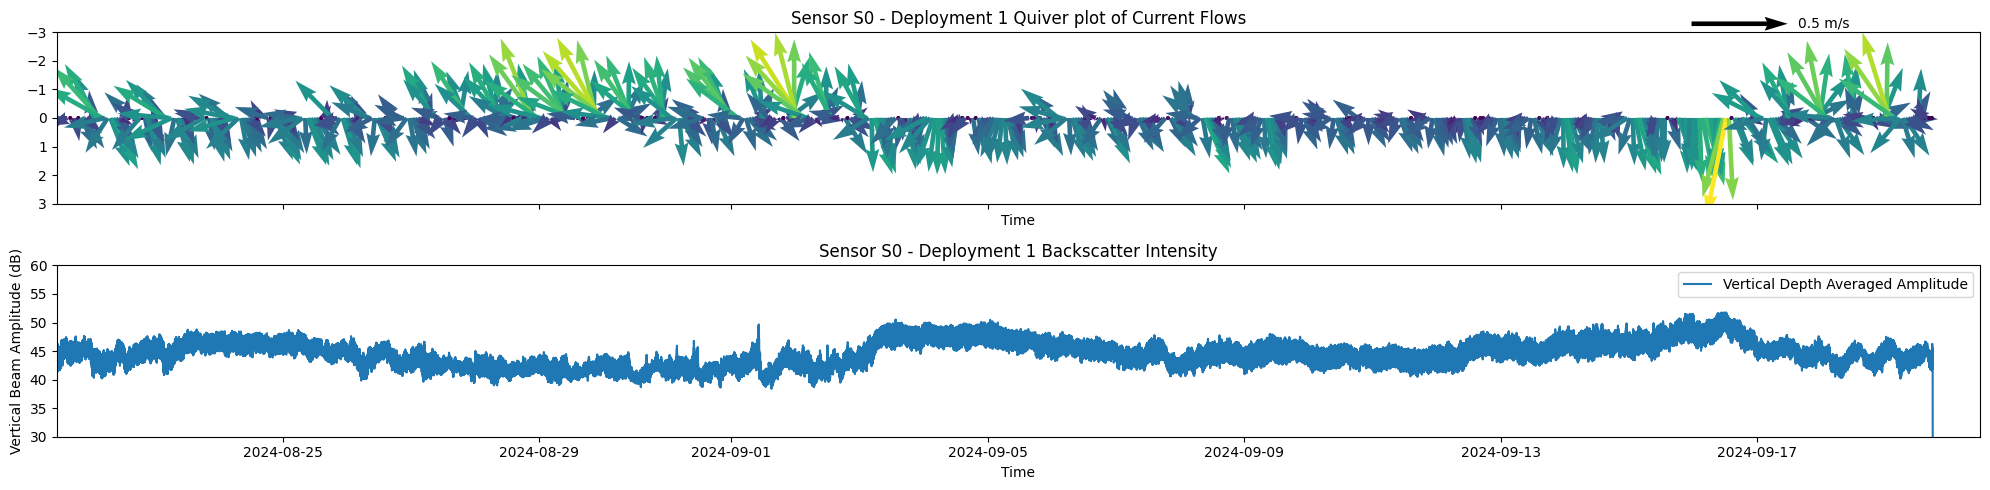

Echo data empty: True


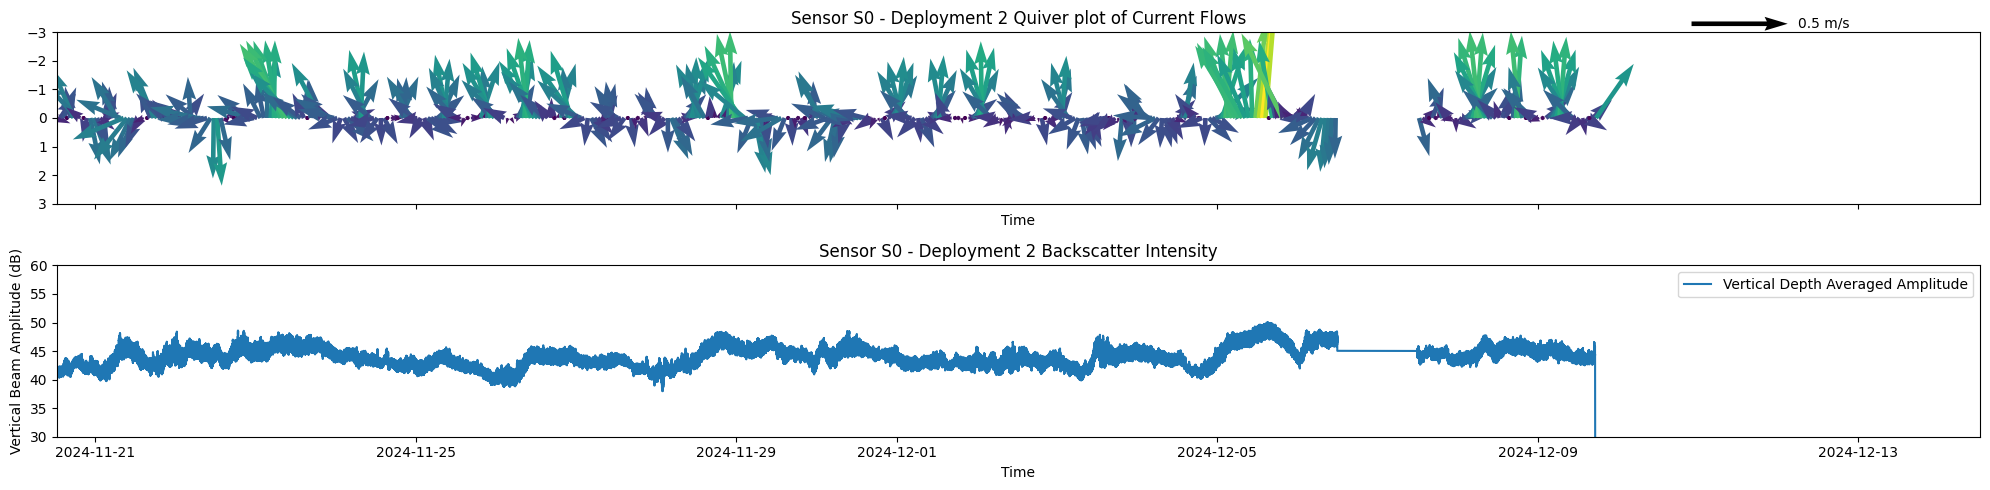

Echo data empty: True


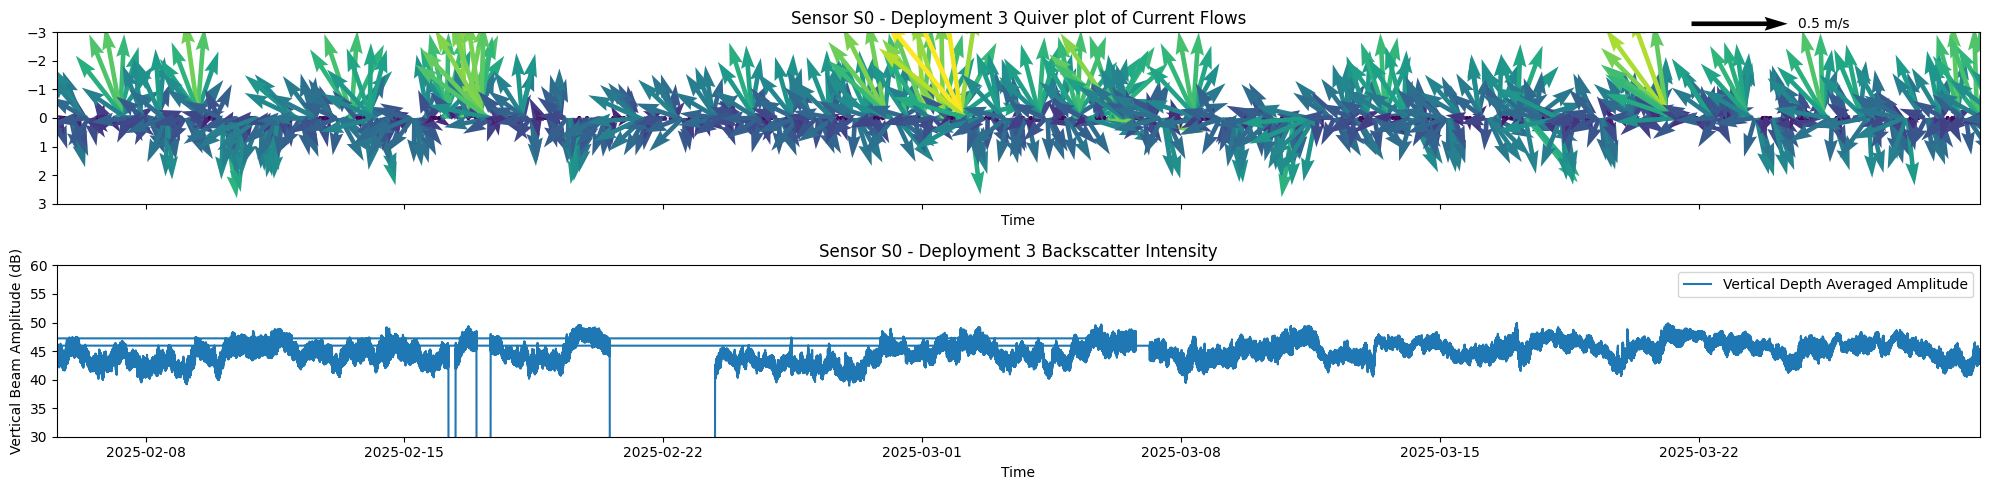

In [ ]:
for side, lander_dict in organized_waves.items():
    for lander_id, dep_dict in lander_dict.items():
        for dep_num, data in dep_dict.items():
            plot_quiver_ampavg(data, title=f"Sensor {side}{lander_id} - Deployment {dep_num}")